# CIFAR-100 Transfer Learning and CPU vs GPU Benchmark

This notebook fine-tunes an ImageNet-pretrained CNN on CIFAR-100 and measures training and inference speed on whatever hardware the Colab runtime provides.

**How to run it**

1. **Accuracy run (GPU runtime).** Set `RUN_MODE = "full"` and run all cells. This trains in two phases (frozen backbone, then fine-tuning) and reports test top-1 and top-5 accuracy.
2. **Hardware benchmark (3 runtimes).** Set `RUN_MODE = "benchmark"`. Switch the runtime to CPU, then T4 GPU, then TPU (*Runtime → Change runtime type*), and run all cells each time. Each run saves a results file to Google Drive.
3. **Compare.** On any runtime, run the last section to build the comparison table and charts from the saved results.

**If Colab disconnects:** progress is saved to Google Drive after every epoch. Reconnect (*Runtime → Connect*), then run all cells again (*Runtime → Run all*) with the **same settings**. Training resumes from the last saved epoch instead of starting over. Free Colab GPUs are limited, so it helps to run the short benchmark runs first and the long accuracy run at a quieter time, such as early morning.

**Fixes compared with the original notebook:** real validation split (the test set is only used once at the end), images upscaled to the backbone's expected resolution, the backbone's own preprocessing instead of `/255`, data augmentation, two-phase fine-tuning, batch size 64 instead of 1, mixed precision on GPU/TPU, average (not snapshot) resource usage, and results saved for comparison.

In [1]:
import os, glob, json, time, platform, subprocess, threading
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import tensorflow as tf
import keras
from keras import layers

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.20.0 | Keras 3.13.2


## 1. Configuration

In [2]:
RUN_MODE = "benchmark"            # "full" = train and report accuracy | "benchmark" = short timed run for hardware comparison
BACKBONE = "DenseNet121"     # "DenseNet121", "ResNet50", "VGG19", "EfficientNetV2B0"
IMG_SIZE = 128               # CIFAR images (32x32) are upscaled to this size
PER_REPLICA_BATCH = 64       # global batch = this x number of devices (8 on a TPU)
EVAL_BATCH = 200             # divides 5,000 and 10,000 exactly, so no test images are dropped

HEAD_EPOCHS = 3              # phase 1: train only the new classifier head
FINETUNE_EPOCHS = 15         # phase 2: fine-tune the whole network (early stopping may end sooner)
HEAD_LR = 1e-3
FINETUNE_LR = 1e-4
LABEL_SMOOTHING = 0.1
VAL_SIZE = 5000              # held out from the 50,000 training images
SEED = 42

BENCH_STEPS = {"TPU": 200, "GPU": 200, "CPU": 20}   # training steps per benchmark epoch
BENCH_EPOCHS = 3                                     # epoch 1 is warm-up (graph compilation) and is reported separately
BENCH_INFER_BATCHES = {"TPU": 50, "GPU": 50, "CPU": 5}

SAVE_TO_DRIVE = True
DRIVE_DIR = "/content/drive/MyDrive/cifar100_benchmark"

keras.utils.set_random_seed(SEED)

# Connect Google Drive now, so checkpoints and results survive a disconnection
OUT_DIR = "results"
if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        OUT_DIR = DRIVE_DIR
    except Exception as e:
        print("Drive not available, saving locally instead:", e)
os.makedirs(OUT_DIR, exist_ok=True)
print("Saving checkpoints and results to:", OUT_DIR)

Mounted at /content/drive
Saving checkpoints and results to: /content/drive/MyDrive/cifar100_benchmark


## 2. Detect hardware

In [3]:
def detect_hardware():
    tpu_hint = os.path.exists("/dev/accel0") or glob.glob("/dev/vfio/[0-9]*") or "COLAB_TPU_ADDR" in os.environ
    if tpu_hint:
        try:
            try:
                resolver = tf.distribute.cluster_resolver.TPUClusterResolver()             # TPU node
            except ValueError:
                resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")  # TPU VM
            tf.config.experimental_connect_to_cluster(resolver)
            tf.tpu.experimental.initialize_tpu_system(resolver)
            strategy = tf.distribute.TPUStrategy(resolver)
            return "TPU", strategy, f"TPU ({strategy.num_replicas_in_sync} cores)"
        except Exception as e:
            print("TPU found but could not be initialised, falling back:", e)
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        name = tf.config.experimental.get_device_details(gpus[0]).get("device_name", "GPU")
        return "GPU", tf.distribute.OneDeviceStrategy("/gpu:0"), name
    cpu = platform.processor() or "CPU"
    try:
        with open("/proc/cpuinfo") as f:
            cpu = next(l.split(":", 1)[1].strip() for l in f if l.startswith("model name"))
    except Exception:
        pass
    return "CPU", tf.distribute.get_strategy(), f"{cpu} ({os.cpu_count()} vCPUs)"

HARDWARE, strategy, DEVICE_NAME = detect_hardware()
REPLICAS = strategy.num_replicas_in_sync
GLOBAL_BATCH = PER_REPLICA_BATCH * REPLICAS

# Mixed precision speeds up GPU (Tensor Cores) and TPU (bfloat16). CPU stays in float32.
POLICY = {"GPU": "mixed_float16", "TPU": "mixed_bfloat16"}.get(HARDWARE, "float32")
keras.mixed_precision.set_global_policy(POLICY)

print(f"Hardware: {HARDWARE} | {DEVICE_NAME} | replicas: {REPLICAS} | global batch: {GLOBAL_BATCH} | precision: {POLICY}")
if RUN_MODE == "full" and HARDWARE == "CPU":
    print("WARNING: a full training run on CPU will take many hours. Use a GPU runtime, or set RUN_MODE = 'benchmark'.")

Hardware: GPU | Tesla T4 | replicas: 1 | global batch: 64 | precision: mixed_float16


## 3. Load data and create a validation split

In [4]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar100.load_data()
y_train_full, y_test = y_train_full.squeeze(), y_test.squeeze()

CLASS_NAMES = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
]
NUM_CLASSES = len(CLASS_NAMES)

# Stratified-enough random split: the test set is kept untouched until final evaluation.
perm = np.random.default_rng(SEED).permutation(len(x_train_full))
val_idx, train_idx = perm[:VAL_SIZE], perm[VAL_SIZE:]
x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]

print(f"Train: {x_train.shape} | Validation: {x_val.shape} | Test: {x_test.shape}")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 1452s 9us/step
Train: (45000, 32, 32, 3) | Validation: (5000, 32, 32, 3) | Test: (10000, 32, 32, 3)


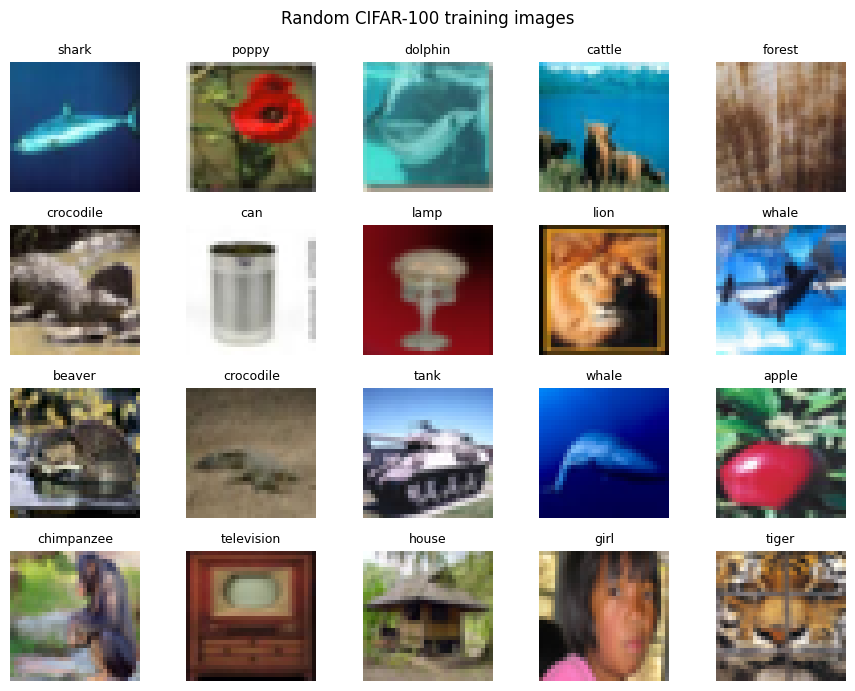

In [5]:
idx = np.random.default_rng(0).choice(len(x_train), 20, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(9, 7))
for ax, i in zip(axes.flat, idx):
    ax.imshow(x_train[i]); ax.set_title(CLASS_NAMES[y_train[i]], fontsize=9); ax.axis("off")
plt.suptitle("Random CIFAR-100 training images"); plt.tight_layout(); plt.show()

## 4. Input pipeline (augmentation)

The CPU only does light work here: flips and crops on the small 32×32 images. Upscaling and the backbone's preprocessing happen **inside the model**, on the GPU or TPU, which is much faster.

In [6]:
BACKBONES = {
    "DenseNet121":      (keras.applications.DenseNet121,      keras.applications.densenet.preprocess_input),
    "ResNet50":         (keras.applications.ResNet50,         keras.applications.resnet.preprocess_input),
    "VGG19":            (keras.applications.VGG19,            keras.applications.vgg19.preprocess_input),
    "EfficientNetV2B0": (keras.applications.EfficientNetV2B0, keras.applications.efficientnet_v2.preprocess_input),
}
BackboneCls, preprocess_fn = BACKBONES[BACKBONE]
AUTOTUNE = tf.data.AUTOTUNE

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.resize_with_crop_or_pad(img, 36, 36)   # pad 2 px on each side
    img = tf.image.random_crop(img, [32, 32, 3])           # then random 32x32 crop
    return img, label

def prepare(img, label):
    return tf.cast(img, tf.float32), tf.one_hot(label, NUM_CLASSES)

def make_ds(x, y, training, batch, repeat=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10_000, seed=SEED)
        if repeat:
            ds = ds.repeat()
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(prepare, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch, drop_remainder=True).prefetch(AUTOTUNE)   # static shapes for TPU

train_ds = make_ds(x_train, y_train, training=True, batch=GLOBAL_BATCH)
val_ds = make_ds(x_val, y_val, training=False, batch=EVAL_BATCH)
test_ds = make_ds(x_test, y_test, training=False, batch=EVAL_BATCH)
STEPS_PER_EPOCH = len(x_train) // GLOBAL_BATCH
print("Training steps per epoch:", STEPS_PER_EPOCH)

Training steps per epoch: 703


## 5. Model

In [7]:
def build_model():
    base = BackboneCls(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inputs = keras.Input((32, 32, 3))
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)   # upscaling runs on the GPU/TPU, not the slow CPU
    x = layers.Lambda(preprocess_fn)(x)               # the backbone's own preprocessing
    x = base(x, training=False)          # keeps BatchNorm statistics frozen, even while fine-tuning
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)  # float32 output for stable loss
    return keras.Model(inputs, outputs), base

def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=[keras.metrics.CategoricalAccuracy(name="accuracy"),
                 keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_accuracy")],
        steps_per_execution=32 if HARDWARE == "TPU" else 1,
    )

with strategy.scope():
    model, base = build_model()
    compile_model(model, HEAD_LR)

print(f"{BACKBONE}: {model.count_params():,} parameters "
      f"({sum(int(np.prod(w.shape)) for w in model.trainable_weights):,} trainable in phase 1)")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
DenseNet121: 7,140,004 parameters (102,500 trainable in phase 1)


## 6. Resource and speed monitoring

In [8]:
def gpu_stats():
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=utilization.gpu,memory.used,memory.total",
                              "--format=csv,noheader,nounits"], capture_output=True, text=True, timeout=5).stdout
        util, used, total = [float(v) for v in out.strip().splitlines()[0].split(",")]
        return util, 100 * used / total
    except Exception:
        return None, None

class ResourceMonitor(keras.callbacks.Callback):
    """Per epoch: training time (excluding validation), images/s, and average CPU, RAM and GPU use."""
    def __init__(self, global_batch, sample_every=1.0):
        super().__init__()
        self.global_batch, self.sample_every = global_batch, sample_every
        self.records, self.phase = [], "train"

    def _sampler(self):
        while not self._stop.is_set():
            util, mem = gpu_stats() if HARDWARE == "GPU" else (None, None)
            self._samples.append((psutil.virtual_memory().percent, util, mem))
            self._stop.wait(self.sample_every)

    def on_epoch_begin(self, epoch, logs=None):
        self._samples, self._steps = [], 0
        self._stop = threading.Event()
        threading.Thread(target=self._sampler, daemon=True).start()
        psutil.cpu_percent(interval=None)          # reset so the next reading is the epoch average
        self.t0 = self.t_last = time.perf_counter()

    def on_train_batch_end(self, batch, logs=None):
        self._steps = batch + 1
        self.t_last = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self._stop.set()
        train_s = self.t_last - self.t0
        mean = lambda i: (float(np.mean([s[i] for s in self._samples if s[i] is not None]))
                          if any(s[i] is not None for s in self._samples) else None)
        rec = {"phase": self.phase, "epoch": len(self.records) + 1, "train_time_s": train_s,
               "images_per_s": self._steps * self.global_batch / train_s if train_s > 0 else None,
               "cpu_pct": psutil.cpu_percent(interval=None), "ram_pct": mean(0),
               "gpu_util_pct": mean(1), "gpu_mem_pct": mean(2)}
        rec.update({k: float(v) for k, v in (logs or {}).items()})
        self.records.append(rec)
        gpu = f" | GPU {rec['gpu_util_pct']:.0f}% util, {rec['gpu_mem_pct']:.0f}% mem" if rec["gpu_util_pct"] is not None else ""
        print(f"  [{self.phase} epoch {rec['epoch']}] {train_s:.1f}s train, {rec['images_per_s']:.0f} img/s | "
              f"CPU {rec['cpu_pct']:.0f}% | RAM {rec['ram_pct']:.0f}%{gpu}")

monitor = ResourceMonitor(GLOBAL_BATCH)

## 7. Train (resumes automatically after a disconnection)

Checkpoints are saved to Drive: after phase 1, after every fine-tuning epoch, and when training finishes. If a finished model already exists for these settings, training is skipped and the notebook goes straight to evaluation.

In [9]:
histories, run_start = [], time.perf_counter()
CKPT_DIR = os.path.join(OUT_DIR, f"checkpoints_{BACKBONE}_{IMG_SIZE}px")
HEAD_WEIGHTS = os.path.join(CKPT_DIR, "after_head.weights.h5")
FINAL_WEIGHTS = os.path.join(CKPT_DIR, "final.weights.h5")
BACKUP_DIR = os.path.join(CKPT_DIR, "finetune_backup")
os.makedirs(CKPT_DIR, exist_ok=True)
RESUMED = False

if RUN_MODE == "full" and os.path.exists(FINAL_WEIGHTS):
    model.load_weights(FINAL_WEIGHTS)
    RESUMED = True
    print("Training already finished in an earlier session. Loaded the final model and skipping to evaluation.")

elif RUN_MODE == "full":
    # Phase 1: train only the new head on top of the frozen backbone
    if os.path.exists(HEAD_WEIGHTS):
        model.load_weights(HEAD_WEIGHTS)
        RESUMED = True
        print("Phase 1 finished in an earlier session. Loaded it and moving to phase 2.")
    else:
        monitor.phase = "head"
        histories.append(model.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS, callbacks=[monitor], verbose=2))
        model.save_weights(HEAD_WEIGHTS)

    # Phase 2: unfreeze the backbone and fine-tune everything with a low, decaying learning rate
    with strategy.scope():
        base.trainable = True
        schedule = keras.optimizers.schedules.CosineDecay(FINETUNE_LR, decay_steps=FINETUNE_EPOCHS * STEPS_PER_EPOCH)
        compile_model(model, schedule)
    if os.path.isdir(BACKUP_DIR) and os.listdir(BACKUP_DIR):
        RESUMED = True
        print("Resuming fine-tuning from the last saved epoch.")
    monitor.phase = "finetune"
    early_stop = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
    backup = keras.callbacks.BackupAndRestore(BACKUP_DIR)   # saves after every epoch, restores after a disconnection
    histories.append(model.fit(train_ds, validation_data=val_ds, epochs=FINETUNE_EPOCHS,
                               callbacks=[backup, monitor, early_stop], verbose=2))
    model.save_weights(FINAL_WEIGHTS)

else:
    # Benchmark: time full fine-tuning (the compute-heavy workload) for a fixed number of steps
    with strategy.scope():
        base.trainable = True
        compile_model(model, FINETUNE_LR)
    monitor.phase = "benchmark"
    bench_ds = make_ds(x_train, y_train, training=True, batch=GLOBAL_BATCH, repeat=True)
    histories.append(model.fit(bench_ds, epochs=BENCH_EPOCHS, steps_per_epoch=BENCH_STEPS[HARDWARE],
                               callbacks=[monitor], verbose=2))

TOTAL_TRAIN_S = time.perf_counter() - run_start
print(f"Total training wall time: {TOTAL_TRAIN_S / 60:.1f} min")

Epoch 1/3
  [benchmark epoch 1] 126.7s train, 101 img/s | CPU 62% | RAM 33% | GPU 49% util, 21% mem
200/200 - 127s - 634ms/step - accuracy: 0.2030 - loss: 3.8736 - top5_accuracy: 0.4263
Epoch 2/3
  [benchmark epoch 2] 75.8s train, 169 img/s | CPU 59% | RAM 35% | GPU 81% util, 28% mem
200/200 - 76s - 379ms/step - accuracy: 0.5023 - loss: 2.4156 - top5_accuracy: 0.8084
Epoch 3/3
  [benchmark epoch 3] 77.6s train, 165 img/s | CPU 63% | RAM 36% | GPU 81% util, 28% mem
200/200 - 78s - 388ms/step - accuracy: 0.6053 - loss: 2.0785 - top5_accuracy: 0.8780
Total training wall time: 4.8 min


## 8. Evaluate on the held-out test set and measure inference speed

In [10]:
results = {}

if RUN_MODE == "full":
    test_loss, test_acc, test_top5 = model.evaluate(test_ds, verbose=0)
    results.update(test_loss=float(test_loss), test_accuracy=float(test_acc), test_top5_accuracy=float(test_top5))
    print(f"Test top-1 accuracy: {test_acc:.2%} | top-5 accuracy: {test_top5:.2%}")

# Inference throughput: one warm-up pass, then a timed pass
infer_ds = test_ds if RUN_MODE == "full" else test_ds.take(BENCH_INFER_BATCHES[HARDWARE])
n_infer = sum(1 for _ in infer_ds) * EVAL_BATCH
model.predict(infer_ds.take(2), verbose=0)
t0 = time.perf_counter()
probs = model.predict(infer_ds, verbose=0)
infer_s = time.perf_counter() - t0
results["inference_images_per_s"] = n_infer / infer_s
print(f"Inference: {n_infer} images in {infer_s:.1f}s ({n_infer / infer_s:.0f} images/s)")

Inference: 10000 images in 10.5s (955 images/s)


In [11]:
if RUN_MODE == "full":
    y_pred = probs.argmax(1)
    y_true = y_test[: len(y_pred)]
    per_class = pd.Series([(y_pred[y_true == c] == c).mean() for c in range(NUM_CLASSES)], index=CLASS_NAMES)
    print("Easiest classes:\n", per_class.nlargest(5).map("{:.0%}".format).to_string())
    print("\nHardest classes:\n", per_class.nsmallest(5).map("{:.0%}".format).to_string())

    idx = np.random.default_rng(1).choice(len(y_true), 20, replace=False)
    fig, axes = plt.subplots(4, 5, figsize=(10, 8))
    for ax, i in zip(axes.flat, idx):
        ok = y_pred[i] == y_true[i]
        ax.imshow(x_test[i]); ax.axis("off")
        ax.set_title(f"pred: {CLASS_NAMES[y_pred[i]]}\ntrue: {CLASS_NAMES[y_true[i]]}",
                     fontsize=8, color="green" if ok else "red")
    plt.suptitle("Test-set predictions (green = correct)"); plt.tight_layout(); plt.show()

## 9. Training curves and resource usage

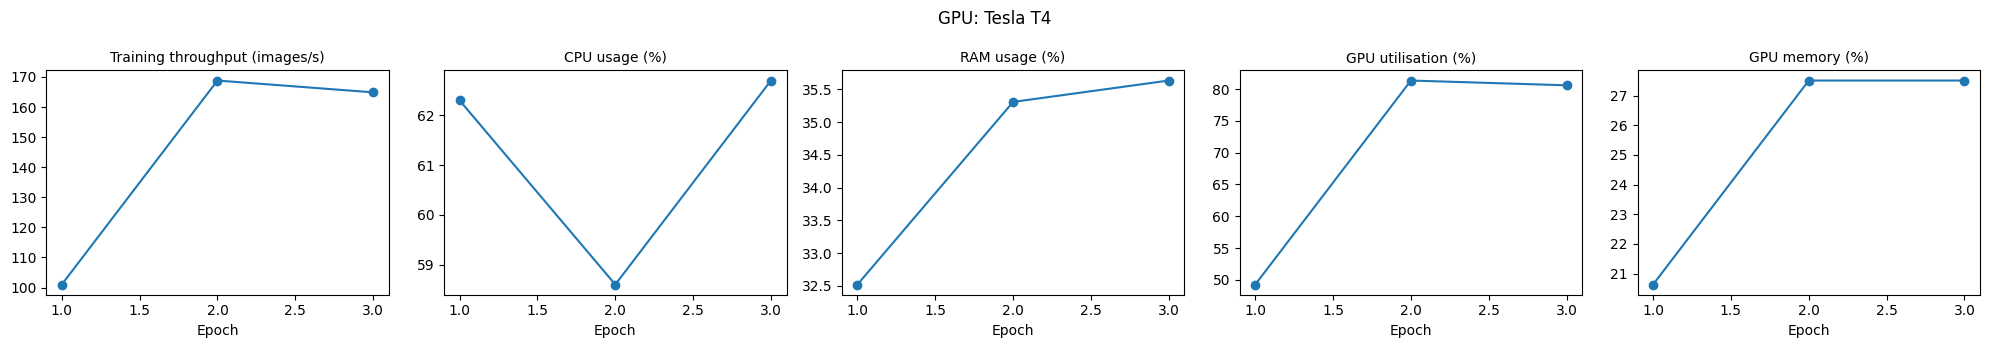

In [12]:
log = pd.DataFrame(monitor.records)
if log.empty:
    print("No training happened in this session (the finished model was loaded), so there are no curves to plot.")
if RESUMED:
    print("Note: this run resumed from a checkpoint, so curves and timings cover only this session.")

if RUN_MODE == "full" and not log.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (metric, title) in zip(axes, [("accuracy", "Top-1 accuracy"), ("top5_accuracy", "Top-5 accuracy"), ("loss", "Loss")]):
        ax.plot(log["epoch"], log[metric], marker="o", label="train")
        ax.plot(log["epoch"], log[f"val_{metric}"], marker="o", label="validation")
        if not RESUMED:
            ax.axvline(HEAD_EPOCHS + 0.5, color="grey", ls="--", lw=1)
        ax.set_title(f"{title} (dashed line = start of fine-tuning)"); ax.set_xlabel("Epoch"); ax.legend()
    plt.tight_layout(); plt.show()

if not log.empty:
    cols = [("images_per_s", "Training throughput (images/s)"), ("cpu_pct", "CPU usage (%)"), ("ram_pct", "RAM usage (%)")]
    if log["gpu_util_pct"].notna().any():
        cols += [("gpu_util_pct", "GPU utilisation (%)"), ("gpu_mem_pct", "GPU memory (%)")]
    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 3.5))
    for ax, (c, title) in zip(np.atleast_1d(axes), cols):
        ax.plot(log["epoch"], log[c], marker="o"); ax.set_title(title, fontsize=10); ax.set_xlabel("Epoch")
    plt.suptitle(f"{HARDWARE}: {DEVICE_NAME}"); plt.tight_layout(); plt.show()

## 10. Save results

In [13]:
steady = log.iloc[1:] if len(log) > 1 else log      # epoch 1 includes graph compilation
has_log = not log.empty
summary = {
    "run_mode": RUN_MODE, "hardware": HARDWARE, "device": DEVICE_NAME, "replicas": REPLICAS,
    "backbone": BACKBONE, "img_size": IMG_SIZE, "global_batch": GLOBAL_BATCH, "precision": POLICY,
    "tf_version": tf.__version__, "timestamp": datetime.now().isoformat(timespec="seconds"),
    "epochs_run": len(log), "total_train_time_min": TOTAL_TRAIN_S / 60,
    "resumed_from_checkpoint": RESUMED,
    "warmup_epoch_s": float(log["train_time_s"].iloc[0]) if has_log else None,
    "train_images_per_s": float(steady["images_per_s"].mean()) if has_log else None,
    "mean_cpu_pct": float(log["cpu_pct"].mean()) if has_log else None,
    "best_val_accuracy": float(log["val_accuracy"].max()) if has_log and "val_accuracy" in log else None,
    **results,
}

path = os.path.join(OUT_DIR, f"{RUN_MODE}_{HARDWARE}_{BACKBONE}_{IMG_SIZE}px.json")
with open(path, "w") as f:
    json.dump(summary, f, indent=2)
if has_log:
    log.to_csv(path.replace(".json", "_epochs.csv"), index=False)
print("Saved", path)
pd.Series(summary)

Saved /content/drive/MyDrive/cifar100_benchmark/benchmark_GPU_DenseNet121_128px.json


,0
run_mode,benchmark
hardware,GPU
device,Tesla T4
replicas,1
backbone,DenseNet121
img_size,128
global_batch,64
precision,mixed_float16
tf_version,2.20.0
timestamp,2026-09-26T03:09:15


## 11. Compare CPU vs GPU vs TPU

Run this after you have run the notebook in benchmark mode on each runtime. It reads every results file saved to Drive.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,device,global_batch,precision,train_images_per_s,inference_images_per_s,warmup_epoch_s
hardware,,,,,,
GPU,Tesla T4,64,mixed_float16,166.85,954.92,126.71


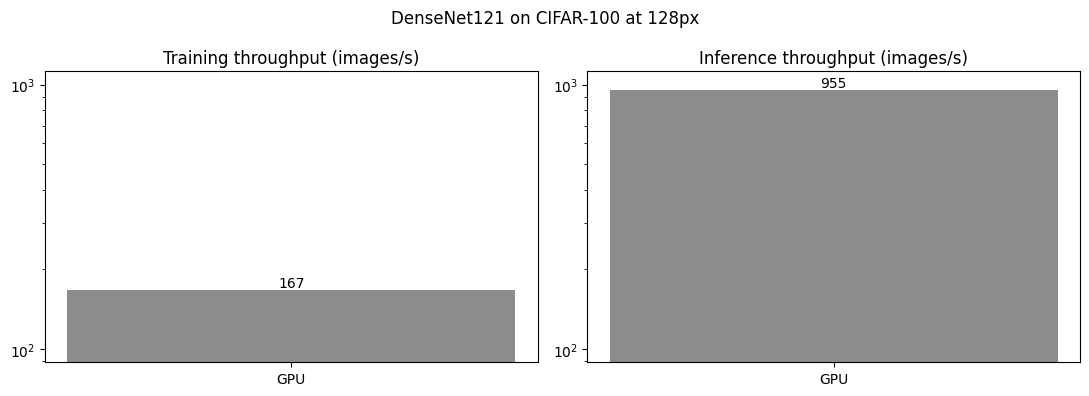

In [14]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    results_dir = DRIVE_DIR
except Exception:
    results_dir = "results"

runs = pd.DataFrame([json.load(open(p)) for p in sorted(glob.glob(os.path.join(results_dir, "*.json")))])
bench = runs[runs["run_mode"] == "benchmark"].drop_duplicates(["hardware", "backbone", "img_size"], keep="last")

if bench.empty:
    print("No benchmark results yet. Run the notebook with RUN_MODE = 'benchmark' on each runtime first.")
else:
    order = [h for h in ["CPU", "GPU", "TPU"] if h in set(bench["hardware"])]
    bench = bench.set_index("hardware").loc[order]
    table = bench[["device", "global_batch", "precision", "train_images_per_s", "inference_images_per_s", "warmup_epoch_s"]].copy()
    if "CPU" in bench.index:
        table["train_speedup_vs_CPU"] = bench["train_images_per_s"] / bench.loc["CPU", "train_images_per_s"]
        table["inference_speedup_vs_CPU"] = bench["inference_images_per_s"] / bench.loc["CPU", "inference_images_per_s"]
    display(table.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (c, title) in zip(axes, [("train_images_per_s", "Training throughput"), ("inference_images_per_s", "Inference throughput")]):
        bars = ax.bar(bench.index, bench[c], color=["#8c8c8c", "#4c72b0", "#dd8452"][: len(bench)])
        ax.bar_label(bars, fmt="%.0f"); ax.set_title(f"{title} (images/s)"); ax.set_yscale("log")
    plt.suptitle(f"{bench['backbone'].iloc[0]} on CIFAR-100 at {bench['img_size'].iloc[0]}px"); plt.tight_layout(); plt.show()

full = runs[runs["run_mode"] == "full"]
if not full.empty:
    display(full[["hardware", "device", "backbone", "img_size", "epochs_run", "total_train_time_min",
                  "best_val_accuracy", "test_accuracy", "test_top5_accuracy"]].round(4))

## What to record for your resume

After the runs, note these numbers from the tables above:

- Test top-1 and top-5 accuracy from the GPU `full` run, plus which backbone and image size you used.
- Training and inference throughput (images/s) for CPU, GPU and TPU, and the speedup over CPU.
- Total fine-tuning time on GPU.

Note that the TPU uses a larger global batch (64 per core × 8 cores), which is standard practice but worth mentioning if you compare it directly with the GPU.